In [26]:
import random
import torch
import datasets
from transformers import BertTokenizerFast, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import f1_score


In [27]:
dataset = load_dataset("dair-ai/emotion")
dataset = datasets.DatasetDict({
    "train": dataset["train"].shuffle(seed=42).select(range(2000)),
    "validation": dataset["validation"].shuffle(seed=42).select(range(500)),
    "test": dataset["test"].shuffle(seed=42).select(range(1000))
})

In [28]:
def evaluate_random(dataset_split):
    y_true = dataset_split["label"]
    y_pred = [random.randint(0, num_labels - 1) for _ in y_true]

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(num_labels)), zero_division=0
    )

    f1_micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    cm = confusion_matrix(y_true, y_pred)

    return acc, precision, recall, f1, (f1_micro, f1_macro, f1_weighted), cm

In [29]:
pretrained = "bert-base-uncased"
tokenizer = BertTokenizerFast.from_pretrained(pretrained)

MAX_LEN = 128

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=MAX_LEN)

dataset = dataset.map(tokenize, batched=True)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

train_loader = torch.utils.data.DataLoader(dataset["train"], batch_size=16, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset["validation"], batch_size=32)
test_loader = torch.utils.data.DataLoader(dataset["test"], batch_size=32)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = BertForSequenceClassification.from_pretrained(pretrained, num_labels=num_labels).to(device)

optimizer = AdamW(model.parameters(), lr=1e-5)
num_epochs = 10

num_training_steps = num_epochs * len(train_loader)
num_warmup_steps = int(0.1 * num_training_steps)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad() 
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        loss.backward()

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} - Loss: {total_loss / len(train_loader):.4f}")



Using device: cuda


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 1: 100%|██████████| 125/125 [00:09<00:00, 13.85it/s]


Epoch 1 - Loss: 1.6718


Epoch 2: 100%|██████████| 125/125 [00:08<00:00, 13.92it/s]


Epoch 2 - Loss: 1.2298


...

Epoch 8 - Loss: 0.1097


Epoch 9: 100%|██████████| 125/125 [00:08<00:00, 13.90it/s]


Epoch 9 - Loss: 0.0872


Epoch 10: 100%|██████████| 125/125 [00:09<00:00, 13.86it/s]

Epoch 10 - Loss: 0.0785


In [31]:
def evaluate_model(model, dataloader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            preds = torch.argmax(outputs.logits, dim=1).cpu().tolist()

            y_pred.extend(preds)
            y_true.extend(labels.cpu().tolist())

    acc = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(num_labels)), zero_division=0
    )

    f1_micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    cm = confusion_matrix(y_true, y_pred)

    return acc, precision, recall, f1, (f1_micro, f1_macro, f1_weighted), cm

In [32]:
acc_rand, prec_rand, rec_rand, f1_rand, f1avg_rand, cm_rand = evaluate_random(dataset["test"])
acc_bert, prec_bert, rec_bert, f1_bert, f1avg_bert, cm_bert = evaluate_model(model, test_loader)


====== RANDOM MODEL ======
Accuracy: 0.178
Precision: [0.27950311 0.38690476 0.08641975 0.15337423 0.14906832 0.02702703]
Recall: [0.15679443 0.1810585  0.19178082 0.18248175 0.20869565 0.17241379]
F1: [0.20089286 0.24667932 0.11914894 0.16666667 0.17391304 0.04672897]
F1 avg (micro, macro, weighted): (0.178, 0.15900496538477663, 0.19910047062348313)

====== BERT MODEL ======
Accuracy: 0.87
Precision: [0.91459075 0.90410959 0.68493151 0.86029412 0.83760684 0.64285714]
Recall: [0.89547038 0.91922006 0.68493151 0.8540146  0.85217391 0.62068966]
F1: [0.90492958 0.91160221 0.68493151 0.85714286 0.84482759 0.63157895]
F1 avg (micro, macro, weighted): (0.87, 0.8058354474961718, 0.8698795154186089)


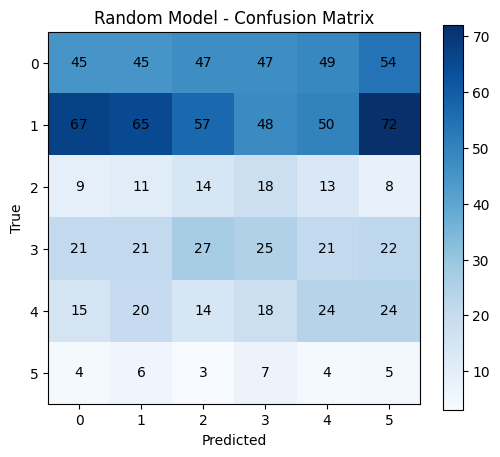

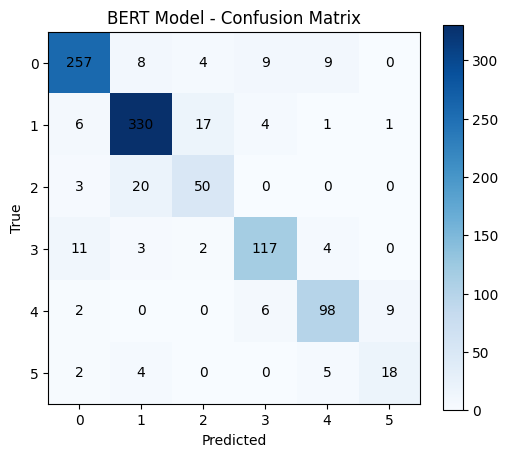

In [33]:
print("\n====== RANDOM MODEL ======")
print("Accuracy:", acc_rand)
print("Precision:", prec_rand)
print("Recall:", rec_rand)
print("F1:", f1_rand)
print("F1 avg (micro, macro, weighted):", f1avg_rand)

print("\n====== BERT MODEL ======")
print("Accuracy:", acc_bert)
print("Precision:", prec_bert)
print("Recall:", rec_bert)
print("F1:", f1_bert)
print("F1 avg (micro, macro, weighted):", f1avg_bert)

def plot_cm(cm, title):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()

    for i in range(num_labels):
        for j in range(num_labels):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.show()

plot_cm(cm_rand, "Random Model - Confusion Matrix")
plot_cm(cm_bert, "BERT Model - Confusion Matrix")


### Analysis of Model Results on the `dair-ai/emotion` Dataset

#### 1. Accuracy Comparison
- **Random model:** 0.178  
- **BERT model:** 0.87  

The BERT model clearly achieves a higher accuracy than the random baseline. However, accuracy should not be treated as the sole evaluation metric, especially for datasets where certain classes appear more frequently than others. In such cases, accuracy may be biased toward majority classes.

---

#### 2. Precision, Recall, and F1 Score per Class
**Random model:**  
- Performance is unstable across classes.  
- Some classes obtain **F1 scores close to zero**, meaning the random classifier essentially never predicts them.  
- Precision and recall values vary unpredictably due to random guessing.

**BERT model:**  
- Significantly higher precision, recall, and F1 for the dominant classes.  
- All metrics show substantial improvement over the random baseline.  
- Lower F1 scores for minority classes indicate that the model still struggles with rare categories.

**Conclusion:**  
BERT provides meaningful improvements over random guessing, but the results also reveal difficulties in modeling underrepresented classes.

---

#### 3. Impact of Class Imbalance on Accuracy
Accuracy can be misleading in imbalanced datasets.  
A model predicting only the most frequent class can achieve deceptively high accuracy while failing to identify minority classes.

Therefore, additional metrics (precision, recall, and F1) are essential for a reliable assessment of model performance.

---

#### 4. Interpretation of Metrics
- **Precision** measures how many predicted samples of a given class are correct.  
- **Recall** measures how many actual samples of a given class were successfully identified.  
- **F1 score** combines precision and recall into a single harmonic-mean measure.  

These metrics provide insights into whether the model **overpredicts**, **underpredicts**, or **ignores** specific classes—information accuracy alone cannot provide.

---

#### 5. Confusion Matrix Interpretation
- **Random model:**  
  Predictions are distributed randomly, with no identifiable structure or patterns.

- **BERT model:**  
  Errors are more systematic.  
  Most misclassifications occur in minority classes or between semantically similar emotions.  
  The confusion matrix reflects meaningful decision boundaries, unlike the random baseline.

---

### Summary
- The BERT model substantially outperforms the random baseline across all evaluation metrics.  
- Accuracy alone is insufficient for assessing model performance on imbalanced datasets.  
- Precision, recall, and F1 scores provide a detailed understanding of model strengths and weaknesses.  
- While BERT handles majority classes effectively, additional techniques (e.g., class reweighting, data augmentation, or sampling strategies) may be required to improve performance on minority classes.
